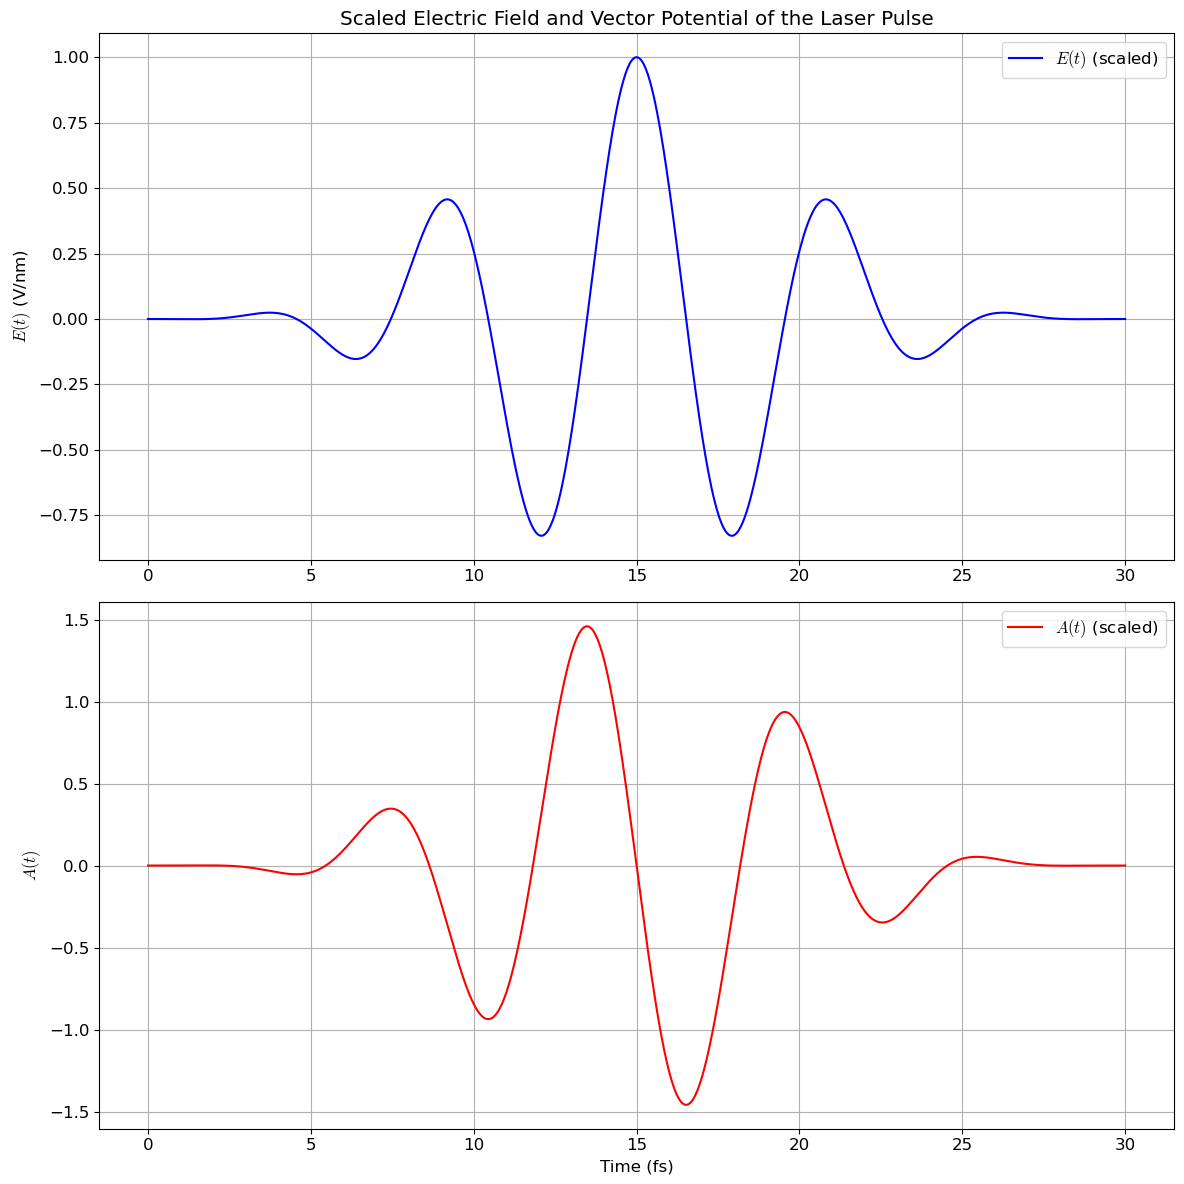

In [12]:
import numpy as np
import math
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

# Set up matplotlib parameters
plt.rcParams.update({'figure.figsize': (12, 12)})
plt.rcParams.update({'font.size': 12})
plt.rcParams["mathtext.fontset"] = "cm"

# Conversion factors
au2Vnm = 5.14220826 * 10**2
au2fs = 0.02418884254
au2eV = 27.2114

# Laser field parameters
F0 = 1 / au2Vnm
w = 0.65 / au2eV
phi0 = 0
tau = 15.0 / au2fs
t0 = 15.0 / au2fs

# Vector potential function
def A(t):
    return np.cos(math.pi * (t - t0) / (2 * tau))**4 * np.sin(w * (t - t0))

# Time grid definitions
tmin = 0.0
tmax = 30.0 / au2fs
Nt = 1000
tgrid = np.linspace(tmin, tmax, Nt)

tgrid_pulse = np.linspace(tmin, tmax, 1000)
Agrid = A(tgrid_pulse)

# Create a spline for A(t)
A_spl = UnivariateSpline(tgrid_pulse, Agrid, s=0)

# Derivative of A(t) to get E(t)
E_spl = A_spl.derivative()

# Evaluate E_spl over the time grid to get its values
E_spl_values = E_spl(tgrid_pulse)

# Find the maximum value of the electric field
Emax = np.max(np.abs(E_spl_values))

# Calculate the scaling factor to make the maximum of E equal to 0.5
scaling_factor = 1 / Emax

# Scale the original vector potential function
Agrid_scaled = Agrid * scaling_factor

# Create a new spline for the scaled vector potential
A_spl_scaled = UnivariateSpline(tgrid_pulse, Agrid_scaled, s=0)

# Derivative of the scaled vector potential to get the new electric field
E_spl_scaled = A_spl_scaled.derivative()

# Plotting the scaled electric field and vector potential
fig, ax = plt.subplots(nrows=2)

# Plot scaled electric field E(t)
ax[0].plot(tgrid_pulse * au2fs, E_spl_scaled(tgrid_pulse), label=r'$E(t)$ (scaled)', color='b')
ax[0].set_ylabel(r'$E(t)$ (V/nm)')
ax[0].set_title('Scaled Electric Field and Vector Potential of the Laser Pulse')
ax[0].legend()
ax[0].grid(True)

# Plot scaled vector potential A(t)
ax[1].plot(tgrid_pulse * au2fs, -A_spl_scaled(tgrid_pulse) / au2eV, label=r'$A(t)$ (scaled)', color='r')
ax[1].set_xlabel(r'Time (fs)')
ax[1].set_ylabel(r'$A(t)$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()



# Writing the field data to a file
with open('field.dat', 'w') as file:
    for it in range(Nt):
        time = tgrid[it]

        # Evaluate the electric field and vector potential
        A = 0.0
        E = 0.0
        if time <= max(tgrid_pulse):
            A = -A_spl_scaled(time)
            E = E_spl_scaled(time)
            Ax = 0.0
            Ay = A
            Ex = 0.0
            Ey = E

        file.write(f"{time * au2fs:.6f} {Ax:.6f} {Ay:.6f} {Ex:.6f} {Ey:.6f}\n")
